<a href="https://colab.research.google.com/github/Melisaoktavia/Pratikum4_Minggu5/blob/main/PCD_MGG5_P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 5.4


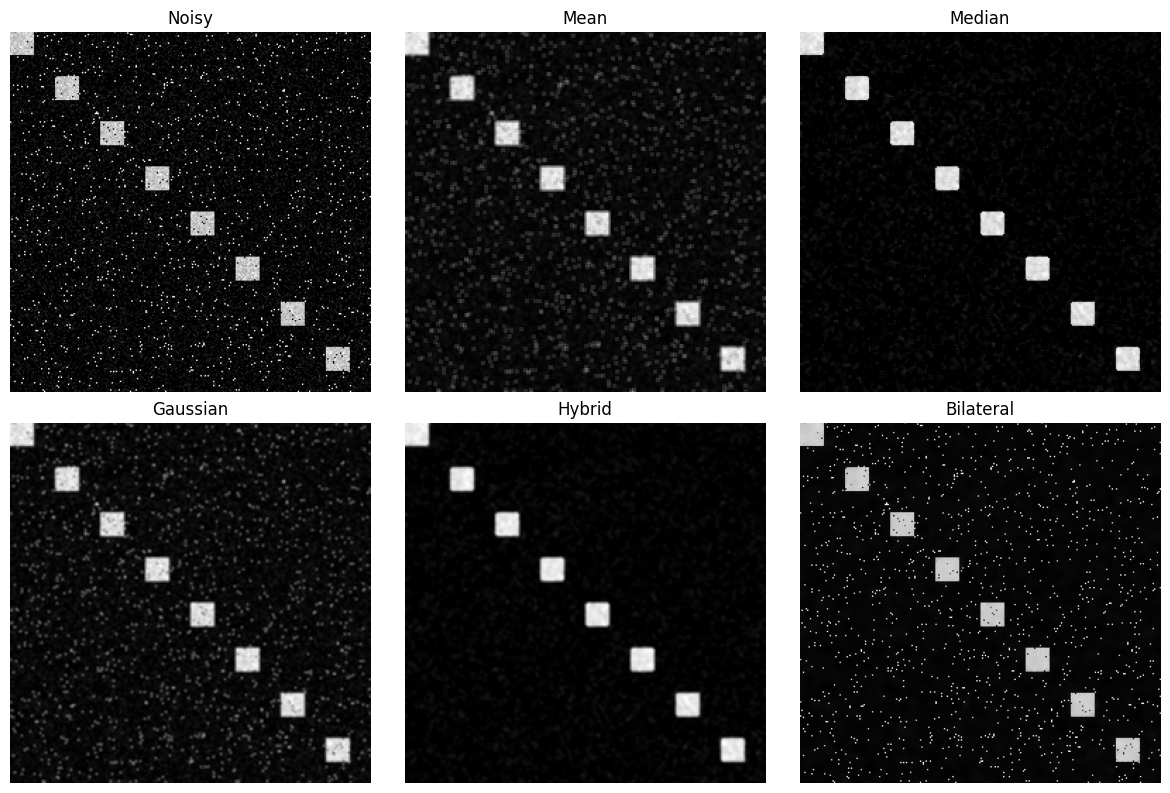

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("PRAKTIKUM 5.4")

clean_img=np.zeros((256,256),dtype=np.uint8)

for i in range(0,256,32):
    cv2.rectangle(clean_img,(i,i),(i+16,i+16),200,-1)

noisy_img=clean_img.astype(float)

gaussian=np.random.normal(0,20,clean_img.shape)
noisy_img+=gaussian

sp=np.random.rand(*clean_img.shape)

noisy_img[sp<0.02]=255
noisy_img[sp>0.98]=0

noisy_img=np.clip(noisy_img,0,255).astype(np.uint8)


def hybrid_filter(image):

    median=cv2.medianBlur(image,3)
    gaussian=cv2.GaussianBlur(median,(3,3),0)

    return gaussian


filters={

    'Noisy':lambda x:x,
    'Mean':lambda x:cv2.blur(x,(3,3)),
    'Median':lambda x:cv2.medianBlur(x,3),
    'Gaussian':lambda x:cv2.GaussianBlur(x,(3,3),0),
    'Hybrid':lambda x:hybrid_filter(x),
    'Bilateral':lambda x:cv2.bilateralFilter(x,9,75,75)

}

fig,axes=plt.subplots(2,3,figsize=(12,8))
axes=axes.ravel()

for i,(name,f) in enumerate(filters.items()):

    img=f(noisy_img)

    axes[i].imshow(img,cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()